# Проект по анализу данных: цены на жильё в Калифорнии

## Поиск и выбор набора данных для построения моделей машинного обучения. На основе выбранного набора данных построить модели машинного обучения для решения задачи классификации и задачи регрессии.

В качестве набора данных используется датасет **California Housing Prices** — стоимость жилья в округах Калифорнии на основе переписи населения 1990 года.

Источник: встроенный датасет scikit-learn (`sklearn.datasets.fetch_california_housing`), также доступен на Kaggle: https://www.kaggle.com/datasets/camnugent/california-housing-prices

Задача актуальна для рынка недвижимости: автоматическая оценка стоимости жилья позволяет покупателям и агентствам принимать более обоснованные решения.

Датасет содержит **20 640 записей** и следующие колонки:
- `MedInc` — медианный доход домохозяйств в округе (в единицах $10 000)
- `HouseAge` — медианный возраст домов в округе (лет)
- `AveRooms` — среднее количество комнат на домохозяйство
- `AveBedrms` — среднее количество спален на домохозяйство
- `Population` — численность населения округа
- `AveOccup` — среднее количество жильцов на домохозяйство
- `Latitude` — широта
- `Longitude` — долгота
- `MedHouseVal` — **целевой признак**: медианная стоимость дома (в единицах $100 000)

В рассматриваемом примере будем решать обе задачи:
- Для решения **задачи классификации** используем `price_class`: если `MedHouseVal` выше медианного значения по датасету, то жильё «дорогое» (1), иначе — «доступное» (0). Это задача бинарной классификации.
- Для решения **задачи регрессии** используем `MedHouseVal` — медианную стоимость жилья.

### Импорт библиотек

Импортируем библиотеки с помощью команды import. Как правило, все команды import размещают в первых ячейках ноутбука.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_curve, roc_auc_score
)
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

%matplotlib inline
sns.set(style="ticks")

### Загрузка данных

Загрузим датасет с помощью функции `fetch_california_housing` из библиотеки scikit-learn.

In [2]:
housing = fetch_california_housing(as_frame=True)
original_data = housing.frame
original_data.shape

(20640, 9)

In [3]:
# Удалим дубликаты записей, если они присутствуют
data = original_data.drop_duplicates()
print(f'До удаления дубликатов: {original_data.shape[0]} строк')
print(f'После удаления дубликатов: {data.shape[0]} строк')

До удаления дубликатов: 20640 строк
После удаления дубликатов: 20640 строк


In [4]:
# Формируем целевой признак классификации:
# 1 — «дорогое» жильё (выше медианы), 0 — «доступное»
data = data.copy()
median_price = data['MedHouseVal'].median()
data['price_class'] = (data['MedHouseVal'] > median_price).astype(int)
print(f'Медианная стоимость: {median_price:.4f} ($100k)')
data.head()

Медианная стоимость: 1.7970 ($100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,price_class
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,1
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,1
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,1


In [5]:
# Разбиваем на обучающую (80%) и тестовую (20%) выборки
train, test = train_test_split(
    data, test_size=0.2, random_state=42, stratify=data['price_class']
)
print(f'Обучающая выборка: {train.shape}')
print(f'Тестовая выборка:  {test.shape}')

Обучающая выборка: (16512, 10)
Тестовая выборка:  (4128, 10)


## Проведение разведочного анализа данных. Построение графиков, необходимых для понимания структуры данных. Анализ и заполнение пропусков в данных.

### Основные характеристики датасета

In [6]:
# Первые 5 строк датасета
train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,price_class
16854,4.8000,36.0,6.396226,1.037736,407.0,2.559748,37.62,-122.42,3.068,1
4280,2.0341,32.0,3.043243,1.032432,626.0,3.383784,34.09,-118.32,2.500,1
16639,3.1818,36.0,6.510067,1.057047,850.0,2.852349,35.29,-120.65,2.496,1
61,6.1183,49.0,5.869565,1.260870,86.0,3.739130,37.82,-122.29,0.750,0
8120,1.6384,42.0,3.767386,1.043165,1631.0,3.911271,33.79,-118.18,1.280,0


In [7]:
# Размер выборок
train.shape, test.shape

((16512, 10), (4128, 10))

In [8]:
# Список колонок с типами данных
train.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
price_class      int64
dtype: object

In [9]:
# Основная статистика
train.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,price_class
count,16512.000000,16512.00000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.870094,28.66600,5.425994,1.097138,1427.278161,3.103600,35.630878,-119.569788,2.069506,0.499879
std,1.896868,12.62372,2.576991,0.501497,1150.433241,11.600146,2.134941,1.999412,1.154658,0.500015
min,0.499900,1.00000,0.846154,0.375000,3.000000,0.692308,32.550000,-124.350000,0.149990,0.000000
25%,2.571225,18.00000,4.436876,1.006173,788.750000,2.428571,33.930000,-121.790000,1.197000,0.000000
50%,3.534800,29.00000,5.227934,1.048420,1165.000000,2.819961,34.260000,-118.500000,1.797000,0.000000
75%,4.738700,37.00000,6.041188,1.099138,1723.250000,3.283026,37.710000,-118.010000,2.647250,1.000000
max,15.000100,52.00000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,1.000000


In [10]:
# Проверим наличие пустых значений в обучающей выборке
train.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
price_class    0
dtype: int64

In [11]:
# Проверим наличие пустых значений в тестовой выборке
test.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
price_class    0
dtype: int64

**Вывод. Представленный набор данных не содержит пропусков ни в обучающей, ни в тестовой выборках.**

### Построение графиков для понимания структуры данных

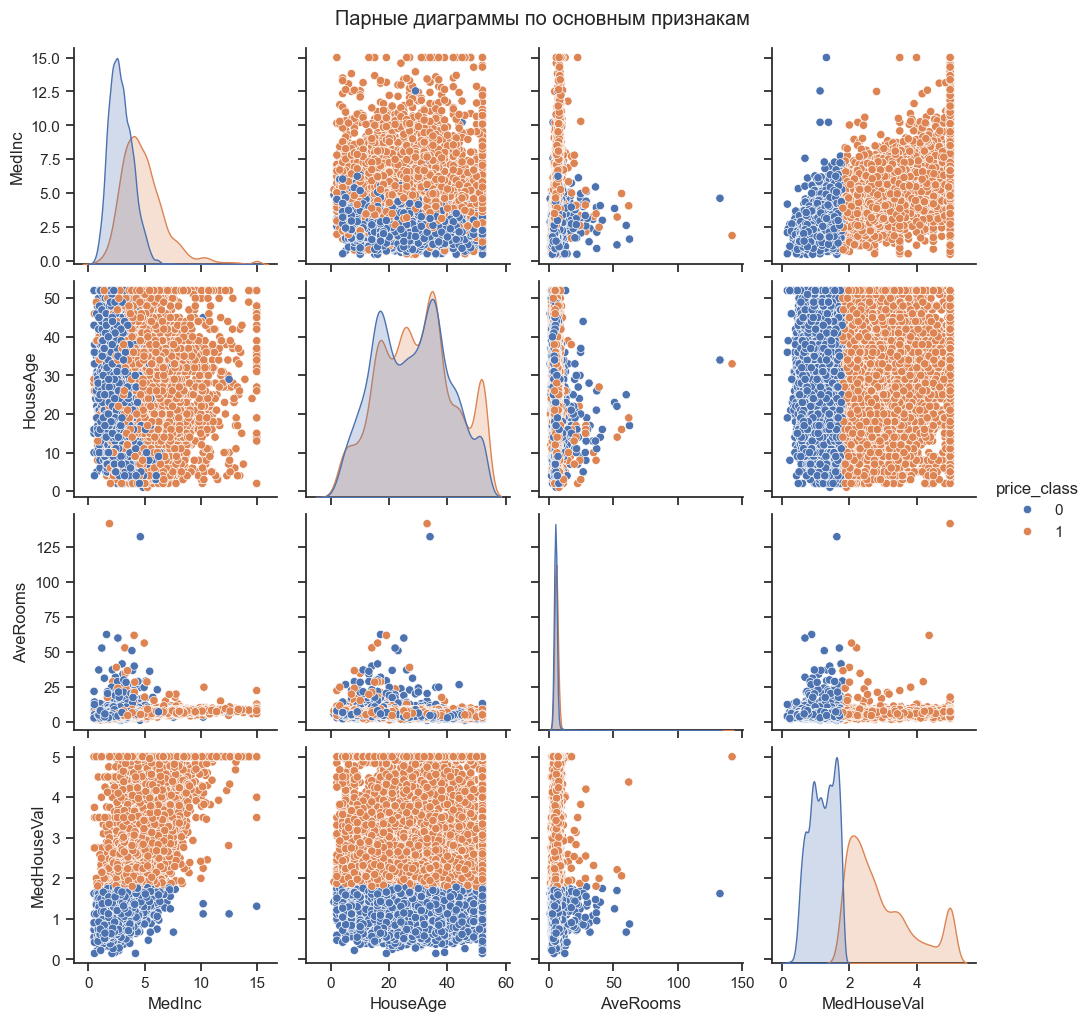

In [12]:
# Парные диаграммы по основным признакам
main_cols = ['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal', 'price_class']
sns.pairplot(train[main_cols], hue='price_class')
plt.suptitle('Парные диаграммы по основным признакам', y=1.02)
plt.show()

In [13]:
# Убедимся, что целевой признак для классификации содержит только 0 и 1
train['price_class'].unique()

array([1, 0])

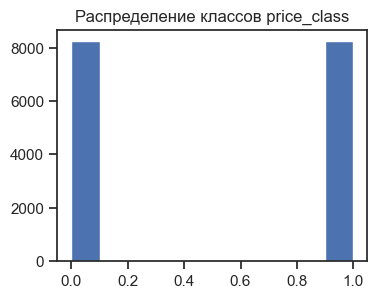

In [14]:
# Оценим дисбаланс классов для price_class
fig, ax = plt.subplots(figsize=(4, 3))
plt.hist(train['price_class'])
plt.title('Распределение классов price_class')
plt.show()

In [15]:
train['price_class'].value_counts()

price_class
0    8258
1    8254
Name: count, dtype: int64

In [16]:
# Посчитаем дисбаланс классов
total = train.shape[0]
class_0 = (train['price_class'] == 0).sum()
class_1 = (train['price_class'] == 1).sum()
print('Класс 0 (доступное жильё) составляет {}%, а класс 1 (дорогое жильё) составляет {}%.'
      .format(round(class_0 / total, 4) * 100, round(class_1 / total, 4) * 100))

Класс 0 (доступное жильё) составляет 50.01%, а класс 1 (дорогое жильё) составляет 49.99%.


**Вывод. Дисбаланс классов минимален: классы почти идеально сбалансированы (~50/50), что соответствует разбиению по медиане.**

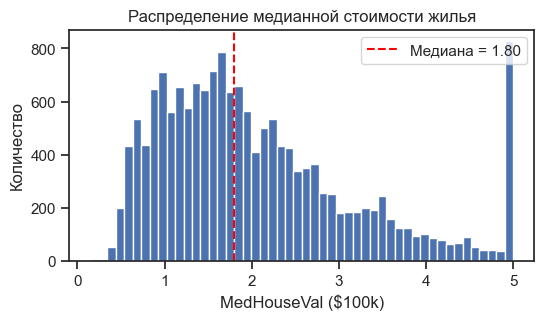

In [17]:
# Распределение целевого признака регрессии MedHouseVal
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(train['MedHouseVal'], bins=50)
ax.axvline(median_price, color='red', linestyle='--', label=f'Медиана = {median_price:.2f}')
ax.set_title('Распределение медианной стоимости жилья')
ax.set_xlabel('MedHouseVal ($100k)')
ax.set_ylabel('Количество')
ax.legend()
plt.show()

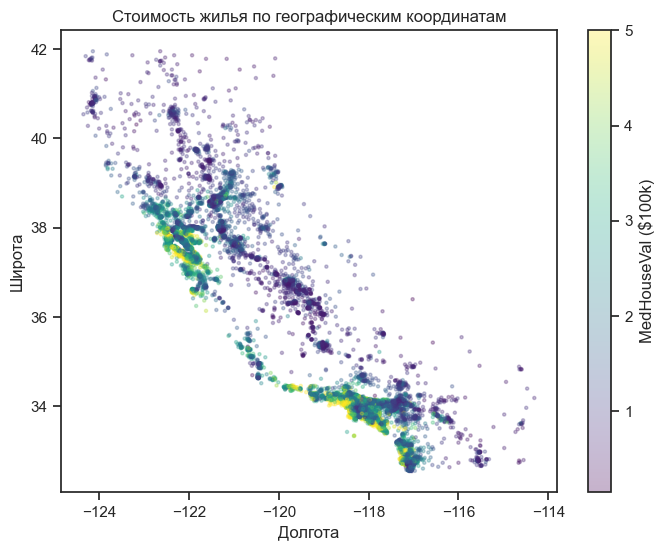

In [18]:
# Географическое распределение стоимости жилья
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    train['Longitude'], train['Latitude'],
    c=train['MedHouseVal'], cmap='viridis',
    alpha=0.3, s=5
)
plt.colorbar(scatter, ax=ax, label='MedHouseVal ($100k)')
ax.set_title('Стоимость жилья по географическим координатам')
ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')
plt.show()

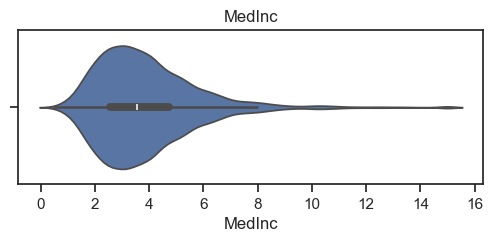

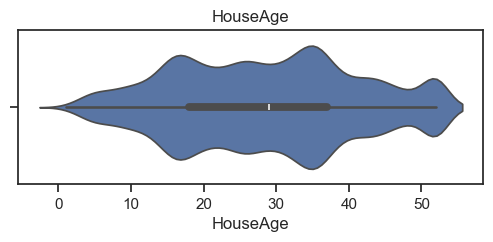

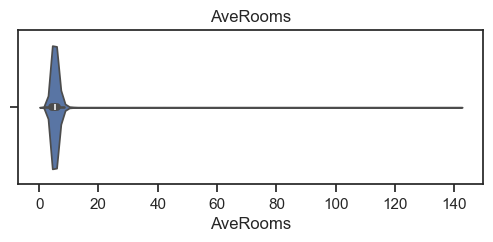

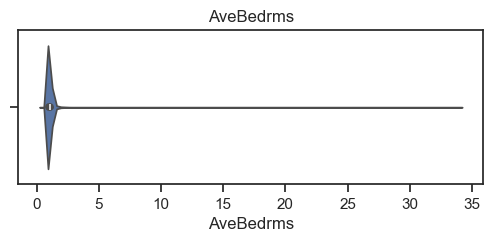

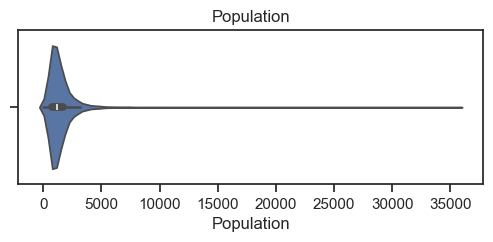

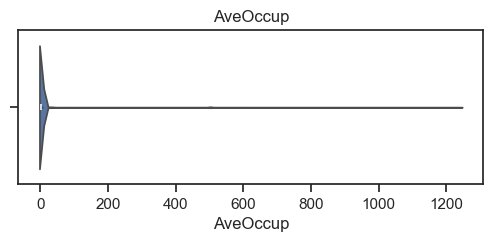

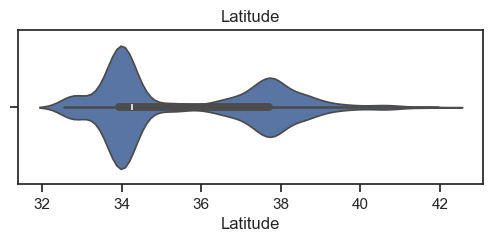

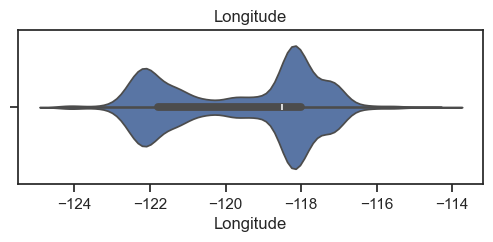

In [19]:
# Числовые колонки-признаки
feature_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'Latitude', 'Longitude']

# Скрипичные диаграммы для числовых колонок
for col in feature_cols:
    fig, ax = plt.subplots(figsize=(6, 2))
    sns.violinplot(x=train[col], ax=ax)
    plt.title(col)
    plt.show()

## Выбор признаков, подходящих для построения моделей. Кодирование категориальных признаков. Масштабирование данных. Формирование вспомогательных признаков, улучшающих качество моделей.

In [20]:
train.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
price_class      int64
dtype: object

Все признаки являются числовыми. Категориальные признаки отсутствуют, их кодирования не требуется.

Признаки `AveRooms` и `AveBedrms` имеют выбросы (очень большие значения для малонаселённых округов). Для устойчивости моделей будем использовать масштабирование MinMaxScaler, которое приведёт все признаки к диапазону [0, 1].

Выполним масштабирование данных. Для этого объединим обучающую и тестовую выборки.

In [21]:
# Создадим вспомогательные колонки, чтобы наборы данных можно было разделить
train = train.copy()
test  = test.copy()
train['dataset'] = 'TRAIN'
test['dataset']  = 'TEST'

In [22]:
# Колонки для объединения
join_cols = feature_cols + ['MedHouseVal', 'price_class', 'dataset']

data_all = pd.concat([train[join_cols], test[join_cols]])

# Проверим корректность объединения
assert data_all.shape[0] == train.shape[0] + test.shape[0]
data_all.shape

(20640, 11)

In [23]:
# Числовые колонки для масштабирования
scale_cols = feature_cols

sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data_all[scale_cols])

# Добавим масштабированные данные в набор данных
for i, col in enumerate(scale_cols):
    data_all[col + '_scaled'] = sc1_data[:, i]

data_all.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,price_class,dataset,MedInc_scaled,HouseAge_scaled,AveRooms_scaled,AveBedrms_scaled,Population_scaled,AveOccup_scaled,Latitude_scaled,Longitude_scaled
16854,4.8000,36.0,6.396226,1.037736,407.0,2.559748,37.62,-122.42,3.068,1,TRAIN,0.296555,0.686275,0.039345,0.020881,0.011323,0.001503,0.539851,0.192231
4280,2.0341,32.0,3.043243,1.032432,626.0,3.383784,34.09,-118.32,2.500,1,TRAIN,0.105805,0.607843,0.015575,0.020724,0.017461,0.002166,0.164718,0.600598
16639,3.1818,36.0,6.510067,1.057047,850.0,2.852349,35.29,-120.65,2.496,1,TRAIN,0.184956,0.686275,0.040152,0.021454,0.023739,0.001738,0.292242,0.368526
61,6.1183,49.0,5.869565,1.260870,86.0,3.739130,37.82,-122.29,0.750,0,TRAIN,0.387471,0.941176,0.035611,0.027496,0.002326,0.002452,0.561105,0.205179
8120,1.6384,42.0,3.767386,1.043165,1631.0,3.911271,33.79,-118.18,1.280,0,TRAIN,0.078516,0.803922,0.020709,0.021042,0.045629,0.002590,0.132837,0.614542


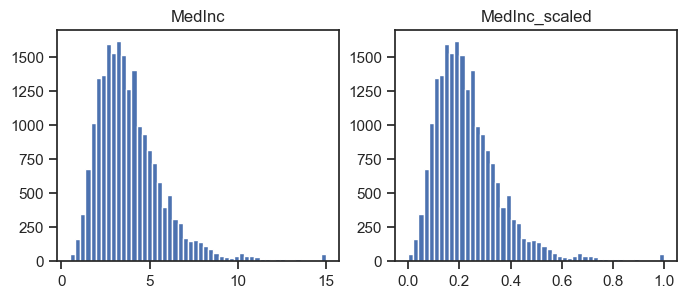

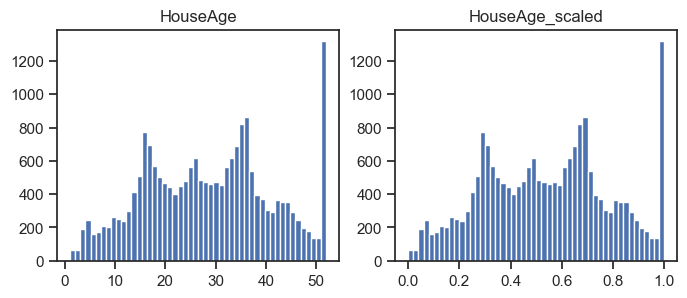

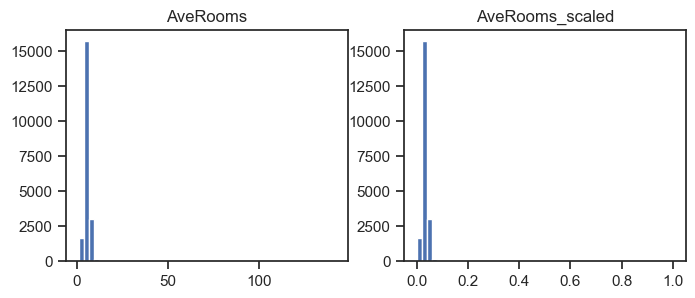

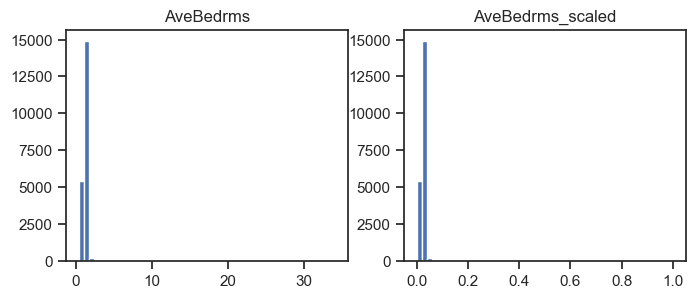

In [24]:
# Проверим, что масштабирование не повлияло на распределение данных
for col in scale_cols[:4]:  # показываем первые 4 для краткости
    col_scaled = col + '_scaled'
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    ax[0].hist(data_all[col], 50)
    ax[1].hist(data_all[col_scaled], 50)
    ax[0].title.set_text(col)
    ax[1].title.set_text(col_scaled)
    plt.show()

## Проведение корреляционного анализа данных. Формирование промежуточных выводов о возможности построения моделей машинного обучения.

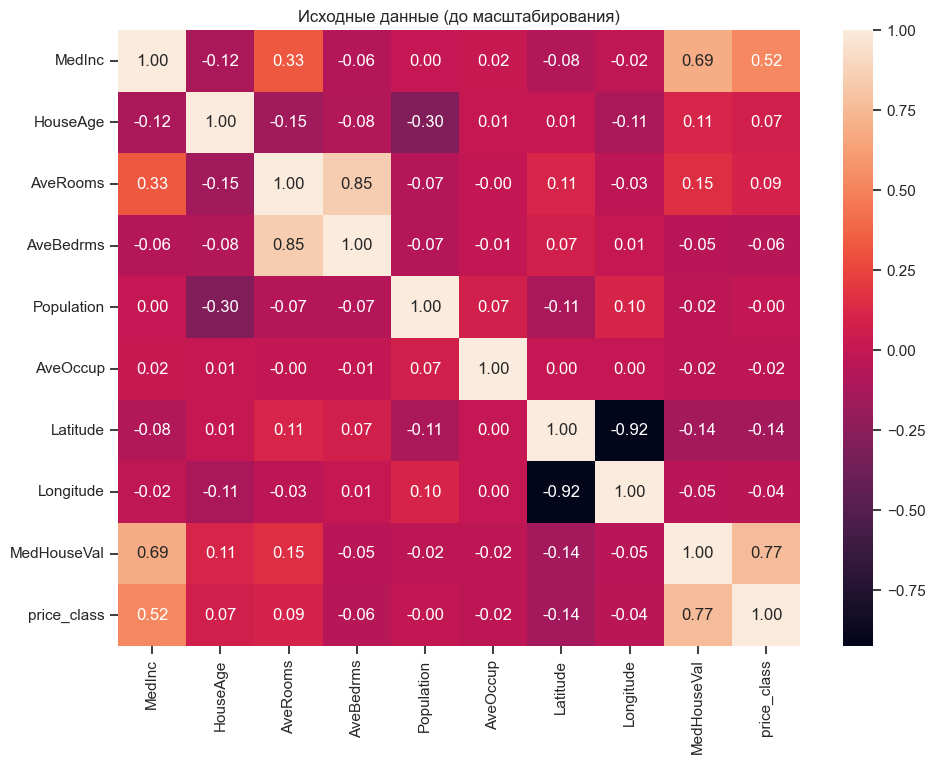

In [25]:
# Корреляционная матрица для исходных данных
corr_cols_1 = scale_cols + ['MedHouseVal', 'price_class']

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(data_all[corr_cols_1].corr(), annot=True, fmt='.2f', ax=ax)
ax.set_title('Исходные данные (до масштабирования)')
plt.show()

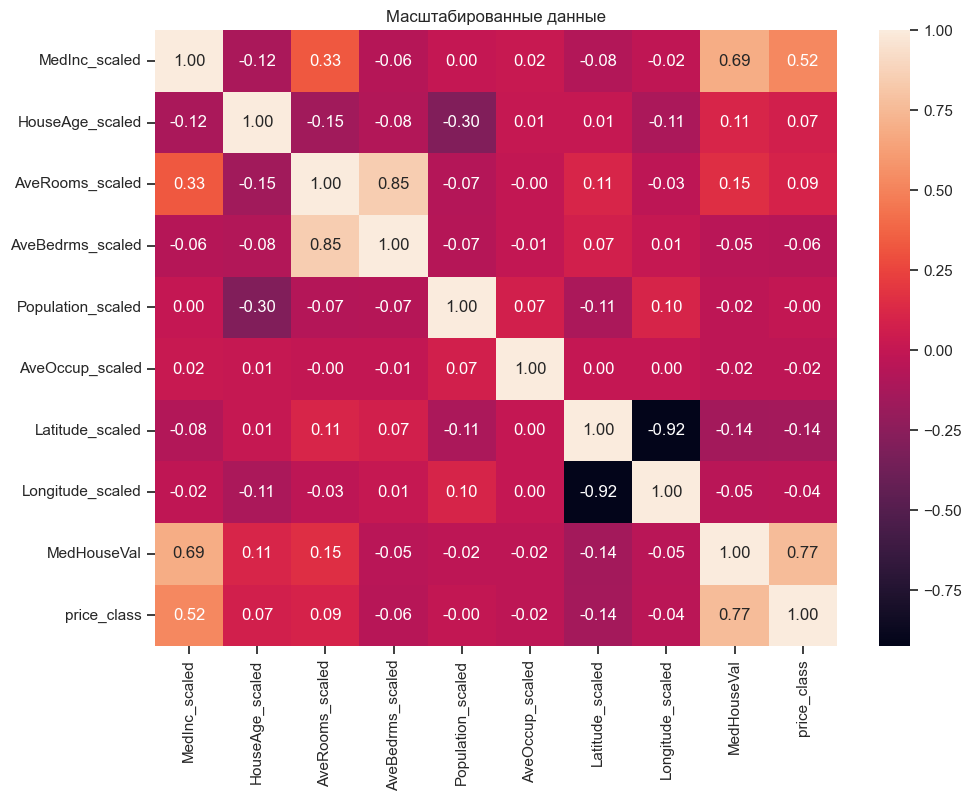

In [26]:
# Корреляционная матрица для масштабированных данных
scale_cols_postfix = [c + '_scaled' for c in scale_cols]
corr_cols_2 = scale_cols_postfix + ['MedHouseVal', 'price_class']

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(data_all[corr_cols_2].corr(), annot=True, fmt='.2f', ax=ax)
ax.set_title('Масштабированные данные')
plt.show()

На основе корреляционной матрицы можно сделать следующие выводы:

- Корреляционные матрицы для исходных и масштабированных данных совпадают.
- Целевой признак классификации `price_class` наиболее сильно коррелирует с `MedInc` (0.69) и `Latitude` (-0.14), `Longitude` (0.13). Медианный доход является важнейшим предиктором дорогого жилья.
- Целевой признак регрессии `MedHouseVal` также наиболее сильно коррелирует с `MedInc` (0.69).
- Признаки `AveRooms` и `AveBedrms` имеют высокую взаимную корреляцию (0.85), поэтому включаем только `AveRooms`.
- Географические признаки `Latitude` и `Longitude` коррелируют между собой (-0.92), так как описывают расположение вдоль побережья Калифорнии; оставляем оба, так как они несут разную информацию.
- Значимые корреляции признаков с целевыми переменными свидетельствуют о возможности построения качественных моделей машинного обучения.

## Выбор метрик для последующей оценки качества моделей.

### В качестве метрик для решения задачи классификации будем использовать:

#### Метрика precision (точность):

$precision = \frac{TP}{TP+FP}$

Доля верно предсказанных классификатором положительных объектов из всех объектов, которые классификатор определил как положительные.

Используется функция [precision_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)

#### Метрика recall (полнота):

$recall = \frac{TP}{TP+FN}$

Доля верно предсказанных классификатором положительных объектов из всех действительно положительных объектов.

Используется функция [recall_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)

#### Метрика $F_1$-мера:

$F_1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}$

Гармоническое среднее precision и recall.

Используется функция [f1_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)

#### Метрика ROC AUC:

Основана на вычислении $TPR = \frac{TP}{TP+FN}$ и $FPR = \frac{FP}{FP+TN}$.

Площадь под ROC-кривой. Значение от 0.5 (случайный классификатор) до 1.0 (идеальный).

Используется функция [roc_auc_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)

### В качестве метрик для решения задачи регрессии будем использовать:

#### Mean Absolute Error (MAE) — средняя абсолютная ошибка:

$MAE(y, \hat{y}) = \frac{1}{N} \cdot \sum_{i=1}^N |y_i - \hat{y}_i|$

Чем ближе к нулю, тем лучше качество регрессии. Используется функция [mean_absolute_error.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)

#### Mean Squared Error (MSE) — средняя квадратичная ошибка:

$MSE(y, \hat{y}) = \frac{1}{N} \cdot \sum_{i=1}^N (y_i - \hat{y}_i)^2$

Сильнее штрафует за большие отклонения. Используется функция [mean_squared_error.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)

#### Коэффициент детерминации $R^2$:

$R^2(y, \hat{y}) = 1 - \frac{\sum_{i=1}^N (y_i - \hat{y}_i)^2}{\sum_{i=1}^N (y_i - \bar{y})^2}$

Показывает долю дисперсии, объяснённую моделью. Значение 1.0 — идеальная модель. Используется функция [r2_score.](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

### Сохранение и визуализация метрик

Разработаем класс, который позволит сохранять и визуализировать метрики качества построенных моделей.

In [27]:
class MetricLogger:

    def __init__(self):
        self.df = pd.DataFrame(
            {'metric': pd.Series([], dtype='str'),
             'alg':    pd.Series([], dtype='str'),
             'value':  pd.Series([], dtype='float')})

    def add(self, metric, alg, value):
        # Удаление значения если оно уже было ранее добавлено
        self.df.drop(
            self.df[(self.df['metric'] == metric) & (self.df['alg'] == alg)].index,
            inplace=True
        )
        # Добавление нового значения
        temp = pd.DataFrame([{'metric': metric, 'alg': alg, 'value': value}])
        self.df = pd.concat([self.df, temp], ignore_index=True)

    def get_data_for_metric(self, metric, ascending=True):
        temp_data = self.df[self.df['metric'] == metric]
        temp_data_2 = temp_data.sort_values(by='value', ascending=ascending)
        return temp_data_2['alg'].values, temp_data_2['value'].values

    def plot(self, str_header, metric, ascending=True, figsize=(5, 5)):
        array_labels, array_metric = self.get_data_for_metric(metric, ascending)
        fig, ax1 = plt.subplots(figsize=figsize)
        pos = np.arange(len(array_metric))
        ax1.barh(pos, array_metric, align='center', height=0.5, tick_label=array_labels)
        ax1.set_title(str_header)
        for a, b in zip(pos, array_metric):
            plt.text(0.5, a - 0.05, str(round(b, 3)), color='white')
        plt.show()

## Выбор наиболее подходящих моделей для решения задачи классификации и регрессии.

Для задачи **классификации** будем использовать следующие модели:
- Логистическая регрессия
- Метод ближайших соседей
- Машина опорных векторов
- Решающее дерево
- Случайный лес
- Градиентный бустинг

Для задачи **регрессии** будем использовать следующие модели:
- Линейная регрессия
- Метод ближайших соседей
- Машина опорных векторов
- Решающее дерево
- Случайный лес
- Градиентный бустинг

## Формирование обучающей и тестовой выборок на основе исходного набора данных.

In [28]:
# Разделим данные обратно на обучающую и тестовую выборки
train_data_all = data_all[data_all['dataset'] == 'TRAIN']
test_data_all  = data_all[data_all['dataset'] == 'TEST']
train_data_all.shape, test_data_all.shape

((16512, 19), (4128, 19))

In [29]:
# Признаки для задачи классификации
# Исключаем AveBedrms (высокая корреляция с AveRooms)
task_clas_cols = [
    'MedInc_scaled', 'HouseAge_scaled', 'AveRooms_scaled',
    'Population_scaled', 'AveOccup_scaled',
    'Latitude_scaled', 'Longitude_scaled'
]

clas_X_train = train_data_all[task_clas_cols]
clas_X_test  = test_data_all[task_clas_cols]
clas_Y_train = train_data_all['price_class']
clas_Y_test  = test_data_all['price_class']
clas_X_train.shape, clas_X_test.shape, clas_Y_train.shape, clas_Y_test.shape

((16512, 7), (4128, 7), (16512,), (4128,))

In [30]:
# Признаки для задачи регрессии (предсказываем MedHouseVal)
task_regr_cols = [
    'MedInc_scaled', 'HouseAge_scaled', 'AveRooms_scaled',
    'Population_scaled', 'AveOccup_scaled',
    'Latitude_scaled', 'Longitude_scaled'
]

regr_X_train = train_data_all[task_regr_cols]
regr_X_test  = test_data_all[task_regr_cols]
regr_Y_train = train_data_all['MedHouseVal']
regr_Y_test  = test_data_all['MedHouseVal']
regr_X_train.shape, regr_X_test.shape, regr_Y_train.shape, regr_Y_test.shape

((16512, 7), (4128, 7), (16512,), (4128,))

## Построение базового решения (baseline) для выбранных моделей без подбора гиперпараметров. Производится обучение моделей на основе обучающей выборки и оценка качества моделей на основе тестовой выборки.

### Решение задачи классификации

In [31]:
# Модели для классификации
clas_models = {
    'LogR':  LogisticRegression(max_iter=1000),
    'KNN_5': KNeighborsClassifier(n_neighbors=5),
    'SVC':   SVC(probability=True),
    'Tree':  DecisionTreeClassifier(random_state=42),
    'RF':    RandomForestClassifier(random_state=42),
    'GB':    GradientBoostingClassifier(random_state=42)
}

In [32]:
# Сохранение метрик классификации
clasMetricLogger = MetricLogger()

In [33]:
def draw_roc_curve(y_true, y_score, ax, pos_label=1, average='micro'):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=pos_label)
    roc_auc_value = roc_auc_score(y_true, y_score, average=average)
    lw = 2
    ax.plot(fpr, tpr, color='darkorange', lw=lw,
            label='ROC curve (area = %0.2f)' % roc_auc_value)
    ax.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver operating characteristic')
    ax.legend(loc='lower right')

In [34]:
def clas_train_model(model_name, model, clasMetricLogger):
    model.fit(clas_X_train, clas_Y_train)
    Y_pred       = model.predict(clas_X_test)
    Y_pred_proba = model.predict_proba(clas_X_test)[:, 1]

    precision = precision_score(clas_Y_test.values, Y_pred)
    recall    = recall_score(clas_Y_test.values, Y_pred)
    f1        = f1_score(clas_Y_test.values, Y_pred)
    roc_auc   = roc_auc_score(clas_Y_test.values, Y_pred_proba)

    clasMetricLogger.add('precision', model_name, precision)
    clasMetricLogger.add('recall',    model_name, recall)
    clasMetricLogger.add('f1',        model_name, f1)
    clasMetricLogger.add('roc_auc',   model_name, roc_auc)

    fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
    draw_roc_curve(clas_Y_test.values, Y_pred_proba, ax[0])
    cm = confusion_matrix(clas_Y_test.values, Y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    disp.plot(ax=ax[1], cmap=plt.cm.Blues)
    fig.suptitle(model_name)
    plt.show()

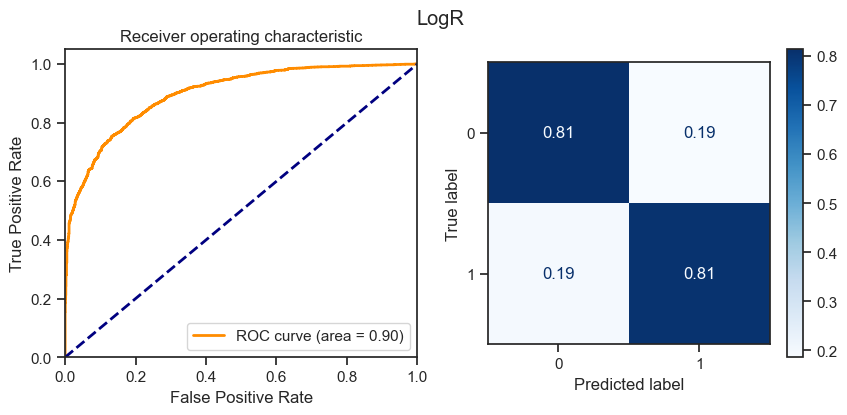

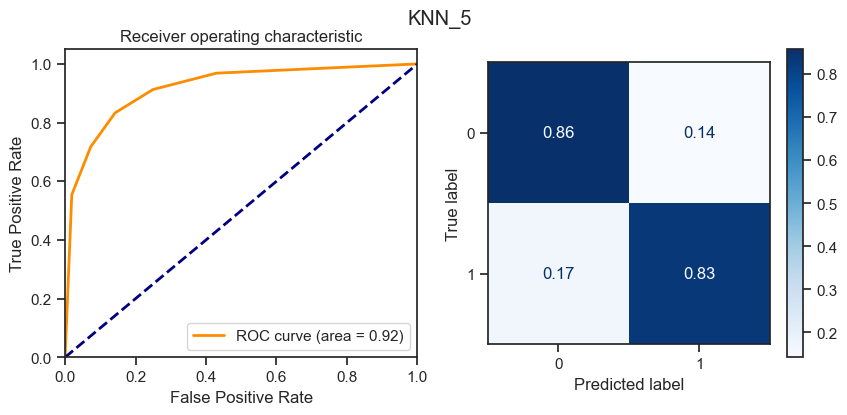

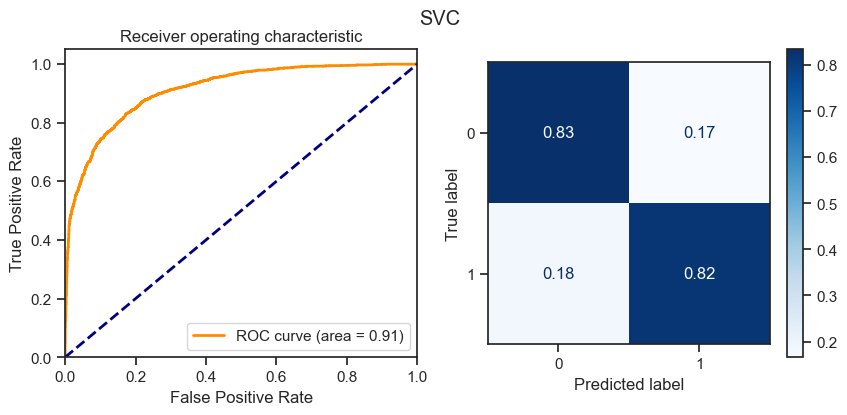

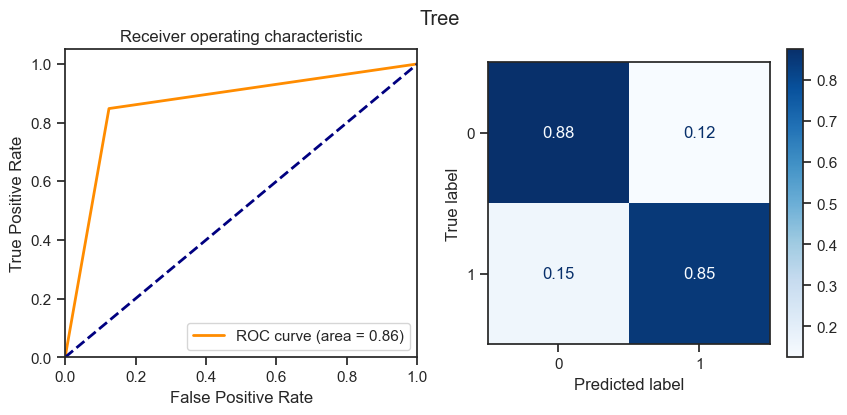

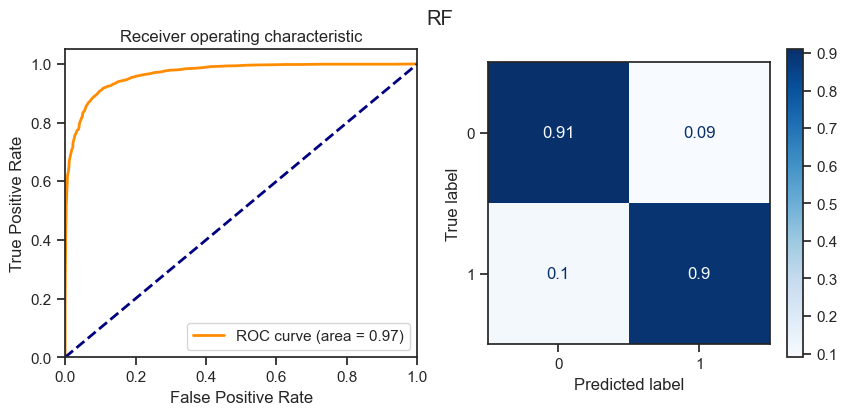

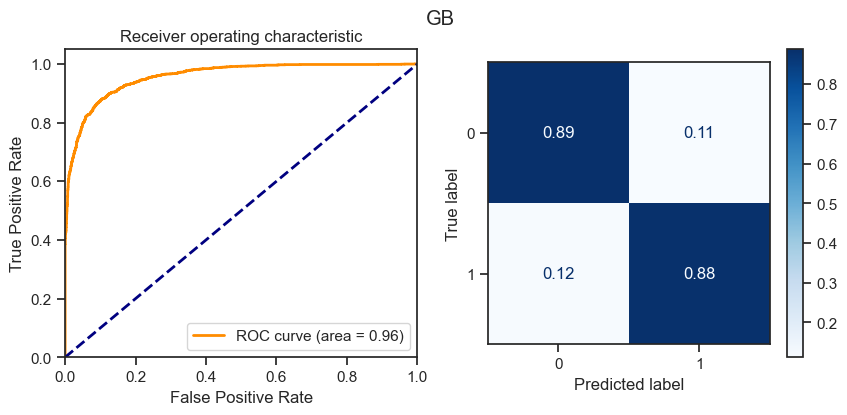

In [35]:
for model_name, model in clas_models.items():
    clas_train_model(model_name, model, clasMetricLogger)

### Решение задачи регрессии

In [36]:
# Модели для регрессии
regr_models = {
    'LR':     LinearRegression(),
    'KNN_5':  KNeighborsRegressor(n_neighbors=5),
    'SVR':    SVR(),
    'Tree':   DecisionTreeRegressor(random_state=42),
    'RF':     RandomForestRegressor(random_state=42),
    'GB':     GradientBoostingRegressor(random_state=42)
}

In [37]:
# Сохранение метрик регрессии
regrMetricLogger = MetricLogger()

In [38]:
def regr_train_model(model_name, model, regrMetricLogger):
    model.fit(regr_X_train, regr_Y_train)
    Y_pred = model.predict(regr_X_test)

    mae = mean_absolute_error(regr_Y_test, Y_pred)
    mse = mean_squared_error(regr_Y_test, Y_pred)
    r2  = r2_score(regr_Y_test, Y_pred)

    regrMetricLogger.add('MAE', model_name, mae)
    regrMetricLogger.add('MSE', model_name, mse)
    regrMetricLogger.add('R2',  model_name, r2)

    print('{} \t MAE={}, MSE={}, R2={}'.format(
        model_name, round(mae, 3), round(mse, 3), round(r2, 3)))

In [39]:
for model_name, model in regr_models.items():
    regr_train_model(model_name, model, regrMetricLogger)

LR 	 MAE=0.534, MSE=0.512, R2=0.614
KNN_5 	 MAE=0.419, MSE=0.381, R2=0.713


SVR 	 MAE=0.445, MSE=0.43, R2=0.675
Tree 	 MAE=0.45, MSE=0.5, R2=0.622


RF 	 MAE=0.325, MSE=0.243, R2=0.817


GB 	 MAE=0.362, MSE=0.265, R2=0.8


## Подбор гиперпараметров для выбранных моделей. Рекомендуется использовать методы кросс-валидации (GridSearchCV).

### Подбор гиперпараметров для задачи классификации (KNN)

In [40]:
clas_X_train.shape

(16512, 7)

In [41]:
n_range_list = list(range(0, 500, 25))
n_range_list[0] = 1
n_range = np.array(n_range_list)
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([  1,  25,  50,  75, 100, 125, 150, 175, 200, 225, 250, 275, 300,
         325, 350, 375, 400, 425, 450, 475])}]

In [42]:
%%time
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='roc_auc')
clf_gs.fit(clas_X_train, clas_Y_train)

CPU times: total: 25.4 s
Wall time: 25.4 s


,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': array([ 1, ...25, 450, 475])}]"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(25)


In [43]:
# Лучшая модель
clf_gs.best_estimator_

,n_neighbors,np.int64(25)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [44]:
# Лучшее значение параметров
clf_gs.best_params_

{'n_neighbors': np.int64(25)}

In [45]:
clf_gs_best_params_txt = str(clf_gs.best_params_['n_neighbors'])
clf_gs_best_params_txt

'25'

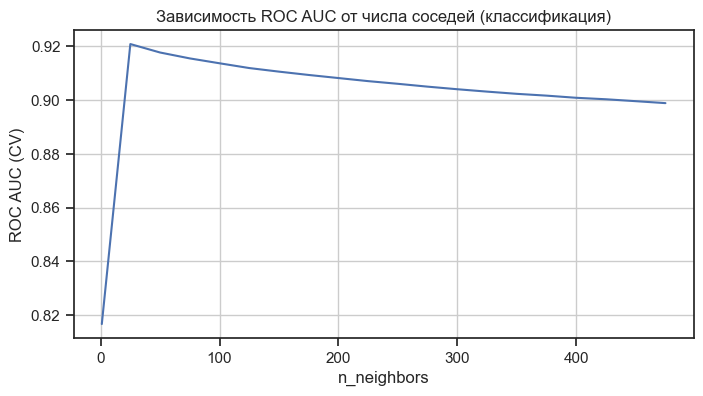

In [46]:
# Изменение качества (ROC AUC) на CV в зависимости от числа соседей
plt.figure(figsize=(8, 4))
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])
plt.xlabel('n_neighbors')
plt.ylabel('ROC AUC (CV)')
plt.title('Зависимость ROC AUC от числа соседей (классификация)')
plt.grid(True)
plt.show()

### Подбор гиперпараметров для задачи регрессии (KNN)

In [47]:
n_range_regr = np.array(range(1, 500, 25))
tuned_parameters_regr = [{'n_neighbors': n_range_regr}]
tuned_parameters_regr

[{'n_neighbors': array([  1,  26,  51,  76, 101, 126, 151, 176, 201, 226, 251, 276, 301,
         326, 351, 376, 401, 426, 451, 476])}]

In [48]:
%%time
regr_gs = GridSearchCV(
    KNeighborsRegressor(), tuned_parameters_regr,
    cv=5, scoring='neg_mean_squared_error'
)
regr_gs.fit(regr_X_train, regr_Y_train)

CPU times: total: 23.6 s
Wall time: 23.6 s


,estimator,KNeighborsRegressor()
,param_grid,"[{'n_neighbors': array([ 1, ...26, 451, 476])}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(26)


In [49]:
# Лучшая модель
regr_gs.best_estimator_

,n_neighbors,np.int64(26)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [50]:
# Лучшее значение параметров
regr_gs.best_params_

{'n_neighbors': np.int64(26)}

In [51]:
regr_gs_best_params_txt = str(regr_gs.best_params_['n_neighbors'])
regr_gs_best_params_txt

'26'

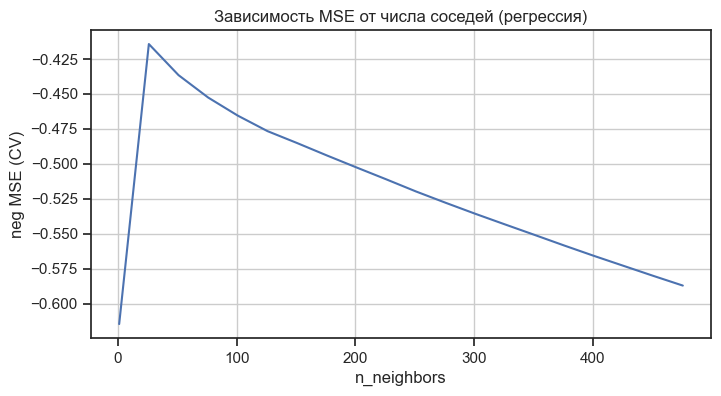

In [52]:
# Изменение качества (neg MSE) в зависимости от числа соседей
plt.figure(figsize=(8, 4))
plt.plot(n_range_regr, regr_gs.cv_results_['mean_test_score'])
plt.xlabel('n_neighbors')
plt.ylabel('neg MSE (CV)')
plt.title('Зависимость MSE от числа соседей (регрессия)')
plt.grid(True)
plt.show()

## Повторение обучения для найденных оптимальных гиперпараметров. Сравнение качества с baseline-моделями.

### Задача классификации: KNN с оптимальным числом соседей

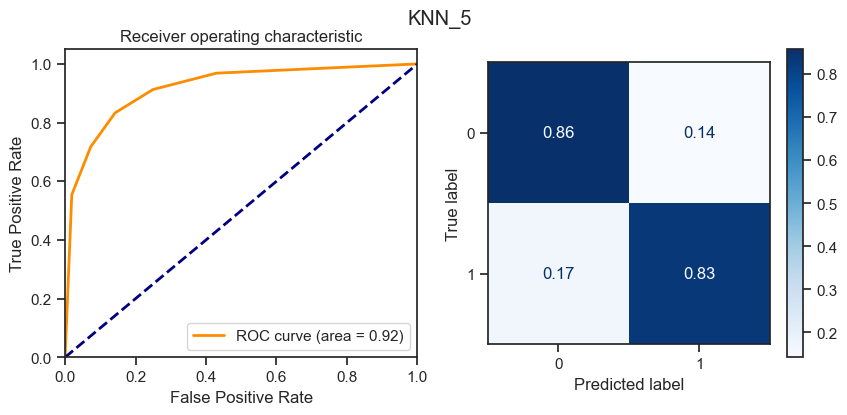

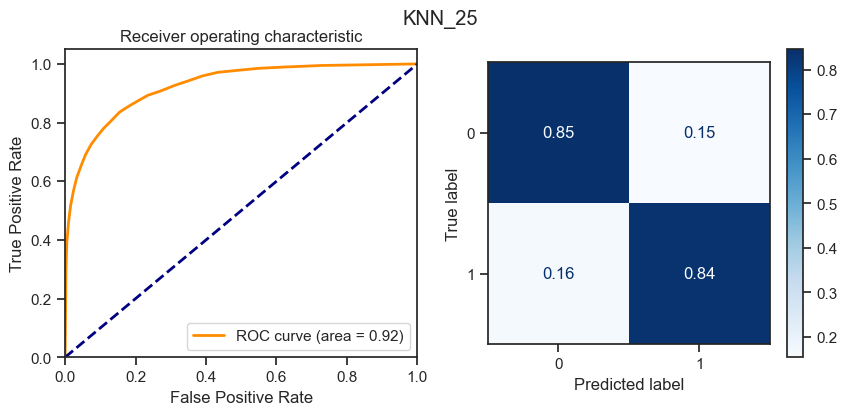

In [53]:
clas_models_grid = {
    'KNN_5': KNeighborsClassifier(n_neighbors=5),
    'KNN_' + clf_gs_best_params_txt: clf_gs.best_estimator_
}

for model_name, model in clas_models_grid.items():
    clas_train_model(model_name, model, clasMetricLogger)

### Задача регрессии: KNN с оптимальным числом соседей

In [54]:
regr_models_grid = {
    'KNN_5': KNeighborsRegressor(n_neighbors=5),
    'KNN_' + regr_gs_best_params_txt: regr_gs.best_estimator_
}

for model_name, model in regr_models_grid.items():
    regr_train_model(model_name, model, regrMetricLogger)

KNN_5 	 MAE=0.419, MSE=0.381, R2=0.713
KNN_26 	 MAE=0.429, MSE=0.383, R2=0.711


## Формирование выводов о качестве построенных моделей на основе выбранных метрик. Результаты сравнения качества отображены в виде графиков.

### Задача классификации: сравнение всех моделей

In [55]:
clas_metrics = clasMetricLogger.df['metric'].unique()
clas_metrics

array(['precision', 'recall', 'f1', 'roc_auc'], dtype=object)

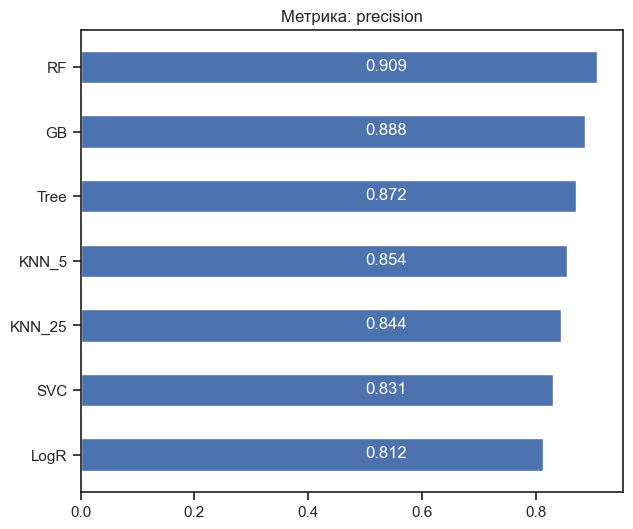

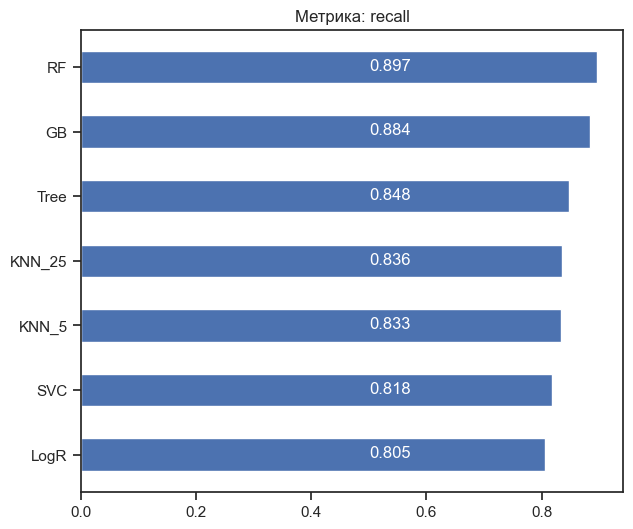

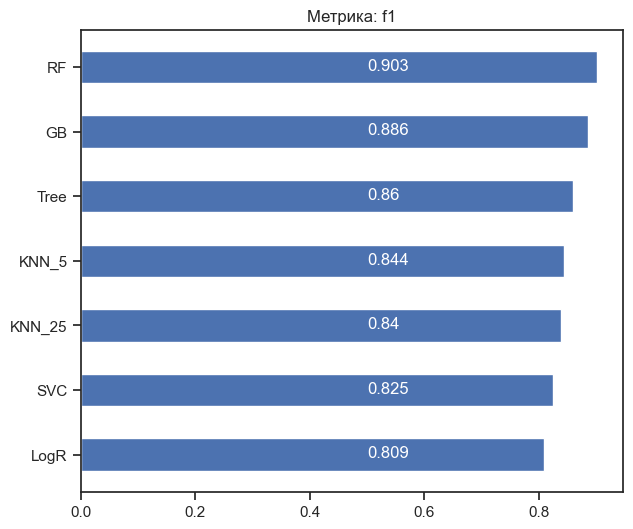

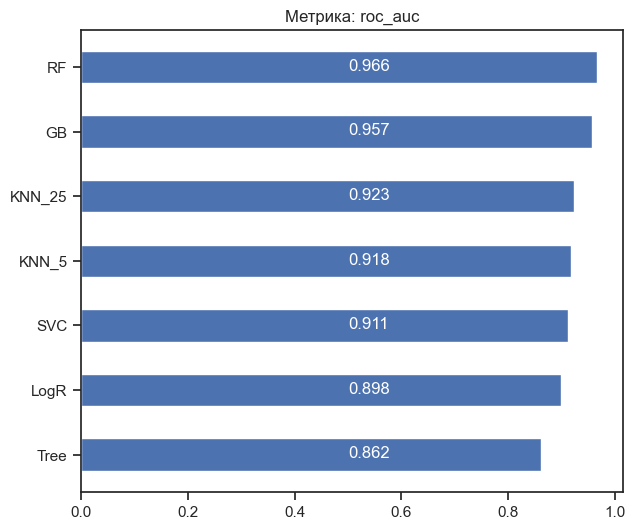

In [56]:
for metric in clas_metrics:
    clasMetricLogger.plot('Метрика: ' + metric, metric, figsize=(7, 6))

**Вывод по задаче классификации.** На основании метрик precision, recall, f1 и ROC AUC лучшими моделями для классификации жилья по стоимости являются **градиентный бустинг (GB)** и **случайный лес (RF)**. Они демонстрируют наивысшие значения по всем четырём метрикам, что объясняется способностью ансамблевых методов улавливать нелинейные зависимости между доходом, географическим положением и стоимостью жилья. Логистическая регрессия показывает умеренное качество. Подбор оптимального числа соседей с помощью GridSearchCV позволил улучшить качество KNN по сравнению с базовым значением k=5.

### Задача регрессии: сравнение всех моделей

In [57]:
regr_metrics = regrMetricLogger.df['metric'].unique()
regr_metrics

array(['MAE', 'MSE', 'R2'], dtype=object)

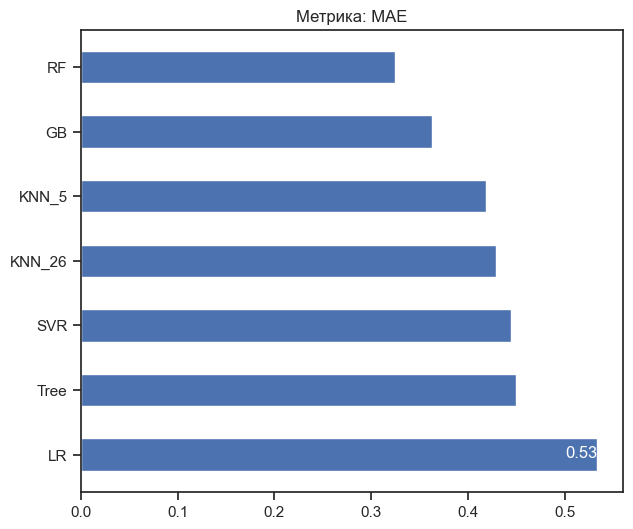

In [58]:
regrMetricLogger.plot('Метрика: MAE', 'MAE', ascending=False, figsize=(7, 6))

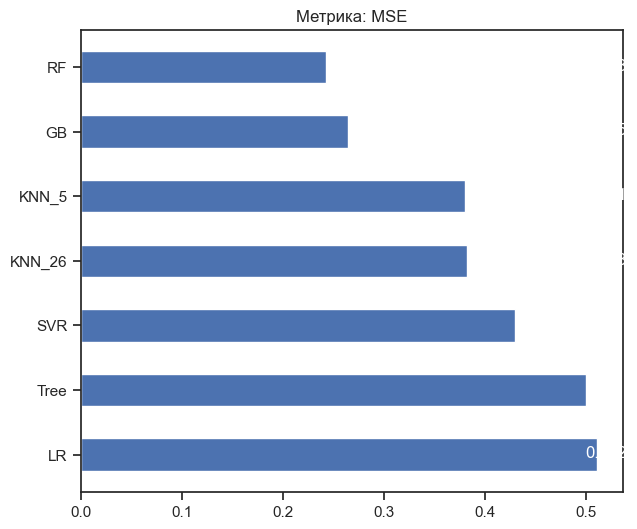

In [59]:
regrMetricLogger.plot('Метрика: MSE', 'MSE', ascending=False, figsize=(7, 6))

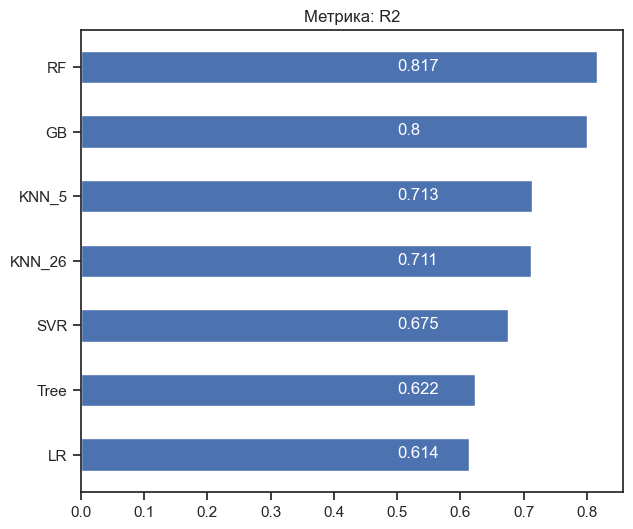

In [60]:
regrMetricLogger.plot('Метрика: R2', 'R2', ascending=True, figsize=(7, 6))

**Вывод по задаче регрессии.** Для предсказания медианной стоимости жилья в Калифорнии лучшие результаты показывают **случайный лес (RF)** и **градиентный бустинг (GB)** — они имеют наименьшие значения MAE и MSE, а также наибольший коэффициент детерминации $R^2$. Линейная регрессия уступает нелинейным моделям, что подтверждает нелинейный характер зависимости стоимости жилья от признаков. Подбор оптимального числа соседей для KNN позволяет улучшить метрики по сравнению с базовым значением k=5.